<a href="https://colab.research.google.com/github/Neethu-Sathyan/playstore_ad_revenue_prediction/blob/main/Full_Code_SuperKart_Sales_Revenue_Model_Deployment_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
!/Users/shaijumr/ml_env/bin/python -m pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.5 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3


In [ ]:
#Installing the libraries with the specified versions
%pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
google-adk 1.23.0 requires requests<3.0.0,>=2.32.4, but you have requests 2.32.3 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.30.1 which is incompatible.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.1 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have hugging

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [ ]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset from a CSV file into a Pandas DataFrame
SuperKart_retail = pd.read_csv("/content/drive/MyDrive/GreatLearning/Model_deployment/AssessmentProject/SuperKart.csv")

In [ ]:
# Create a copy of dataframe
SuperKart_dataset=SuperKart_retail.copy()

In [ ]:
from google.colab import data_table
data_table.disable_dataframe_formatter()

# **Data Overview**

In [ ]:
SuperKart_dataset.shape

(8763, 12)

There are 8763 raw of data and 12 columns of data in data set

In [ ]:
SuperKart_dataset.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [ ]:
SuperKart_dataset.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


The first 5 rows of the dataset

In [ ]:
SuperKart_dataset.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

The column used in the dataset are Product_Id,Product_Weight,Product_Sugar_Content,
Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year, Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total

In [ ]:
SuperKart_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


* There are 5 numerical columns and 7 categorical columns are used in the dataset.
The numerical columns are Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total.
* The categorical columns are Product_Id,Product_Sugar_Content,Product_Type,Store_Id,Store_Size,Store_Location_City_Type,Store_Type
* There are no null values present

In [ ]:
# Drop case_id column as it has no significance
SuperKart_dataset.drop('Product_Id',axis=1,inplace=True)

In [ ]:
# Check for the missing values
SuperKart_dataset.isnull().sum()

Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

There is no missing values in the dataset

In [ ]:
#Check for the duplicate value
SuperKart_dataset.duplicated().sum()

np.int64(0)

In [ ]:
# Numerical columns (int, float, etc.)
numerical_columns = SuperKart_dataset.select_dtypes(include=['number']).columns.tolist()

# Categorical columns (object, category, bool, etc.)
categorical_columns = SuperKart_dataset.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
# Indicates the total revenue generated by the sale of that particular product in that particular store
target='Product_Store_Sales_Total'

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)
print("Target column:",target)

Numerical columns: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical columns: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
Target column: Product_Store_Sales_Total


In [ ]:
# Check for any negative values in the rows
for col in numerical_columns:
    negative_count = (SuperKart_dataset[col] < 0).sum()
    if negative_count > 0:
        print(f"Column '{col}' has {negative_count} negative values.")
    else:
        print(f"Column '{col}' has no negative values.")


Column 'Product_Weight' has no negative values.
Column 'Product_Allocated_Area' has no negative values.
Column 'Product_MRP' has no negative values.
Column 'Store_Establishment_Year' has no negative values.
Column 'Product_Store_Sales_Total' has no negative values.


In [ ]:
# Check the sample
SuperKart_dataset.sample()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
1429,10.92,No Sugar,0.142,Health and Hygiene,184.73,OUT003,1999,Medium,Tier 1,Departmental Store,5972.25


# **Exploratory Data Analysis (EDA)**

In [ ]:
# Define the target variables for regression task
# Indicates the total revenue generated by the sale of that particular product in that particular store
target='Product_Store_Sales_Total'

# Numerical columns (int, float, etc.)
numerical_cols = SuperKart_dataset.select_dtypes(include=['number']).columns.tolist()

# Categorical columns (object, category, bool, etc.)
categorical_cols = SuperKart_dataset.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [ ]:
# Check for the stastistical descriptions of each columns
SuperKart_dataset.describe()


,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


* Product_Weight
   * Product weight has a mean of 12.65 units (SD = 2.22), spans from 4 to 22 units, and shows a symmetric distribution centered around a median of 12.66.
* Product_Allocated_Area
  * Product_Allocated_Area is generally low, with a mean of 0.069 and a median of 0.056, ranging from 0.004 to 0.298 and exhibiting a right-skewed distribution.
* Product_MRP
  * Product_MRP has an average value of 147.03 (SD = 30.69), spans from 31 to 266, and follows a roughly symmetric distribution with a median of 146.74 and an interquartile range of 126.16–167.59.
* Store_Establishment_Year
  * Store_Establishment_Year spans 1987–2009 (mean 2002.03), but the median and 75th percentile both equal 2009, indicating at least half the stores were established that year.
* Product_Store_Sales_Total
  * Product_Store_Sales_Total has a mean of 3,464.00 (SD = 1,065.63), ranges from 33 to 8,000, and displays a roughly symmetric distribution with a median of 3,452.34 and an interquartile range of 2,761.72–4,145.17.


In [ ]:
SuperKart_dataset[categorical_columns].describe()

In [ ]:
SuperKart_dataset[categorical_columns].describe()

,Product_Sugar_Content,Product_Type,Store_Id,Store_Size,Store_Location_City_Type,Store_Type
count,8763,8763,8763,8763,8763,8763
unique,4,16,4,3,3,4
top,Low Sugar,Fruits and Vegetables,OUT004,Medium,Tier 2,Supermarket Type2
freq,4885,1249,4676,6025,6262,4676


* The dataset includes 8,763 distinct product records from four stores, with “Low Sugar” items and “Fruits and Vegetables” emerging as the most common categories. Most sales are generated in medium-sized Tier 2 cities through Supermarket Type2 outlets, with Store OUT004 accounting for the highest sales occured.

In [ ]:
print("Total number of different product type",SuperKart_dataset['Product_Type'].nunique())
print(SuperKart_dataset['Product_Type'].value_counts())


Total number of different product type 16
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64


There are 16 different types of products are used for sales.

In [ ]:
print(SuperKart_dataset['Product_Sugar_Content'].value_counts())
SuperKart_dataset['Product_Sugar_Content'].unique()

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64


array(['Low Sugar', 'Regular', 'No Sugar', 'reg'], dtype=object)

In [ ]:
# Check the product types where Sugar_Content is reg
SuperKart_dataset[SuperKart_dataset['Product_Sugar_Content'].isin(['reg'])]['Product_Type'].value_counts()

,count
Product_Type,
Frozen Foods,16
Baking Goods,14
Fruits and Vegetables,13
Snack Foods,11
Canned,11
Meat,9
Soft Drinks,8
Dairy,7
Hard Drinks,6


In [ ]:
# Check the product types where Sugar_Content is reg
SuperKart_dataset[SuperKart_dataset['Product_Sugar_Content'].isin(['Regular'])]['Product_Type'].value_counts()

Product_Type
Fruits and Vegetables    372
Snack Foods              334
Canned                   264
Frozen Foods             264
Baking Goods             240
Meat                     232
Dairy                    199
Soft Drinks              141
Hard Drinks               52
Breads                    49
Starchy Foods             40
Breakfast                 38
Seafood                   26
Name: count, dtype: int64

* The dataset shows four different kinds (Low Sugar,Regular,No Sugar,reg') of sugar content
* The previous results indicate that 'reg' was a typo, as its product types match those of 'Regular'.
* Therefore, 'reg' should be replaced with 'Regular'.

In [ ]:
# Replace Sugar Content reg with Regular
SuperKart_dataset['Product_Sugar_Content'].replace('reg', 'Regular', inplace=True)

In [ ]:
SuperKart_dataset['Product_Sugar_Content'].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

The 'reg' is replaced by 'Regular'

In [ ]:
print("Total number of different store size",SuperKart_dataset['Store_Size'].nunique())
print(SuperKart_dataset['Store_Size'].value_counts())


Total number of different store size 3
Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64


There are 3 different store size are used for sales.

In [ ]:
print("Total number of different Store Location City type ",SuperKart_dataset['Store_Location_City_Type'].nunique())
print(SuperKart_dataset['Store_Location_City_Type'].value_counts())


Total number of different Store Location City type  3
Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64


There are 3 different Store Location City type are used for sales.

In [ ]:
print("Total number of different Store type ",SuperKart_dataset['Store_Type'].nunique())
print(SuperKart_dataset['Store_Type'].value_counts())


Total number of different Store type  4
Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64


There are 4 different Store type are used for sales.

## Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

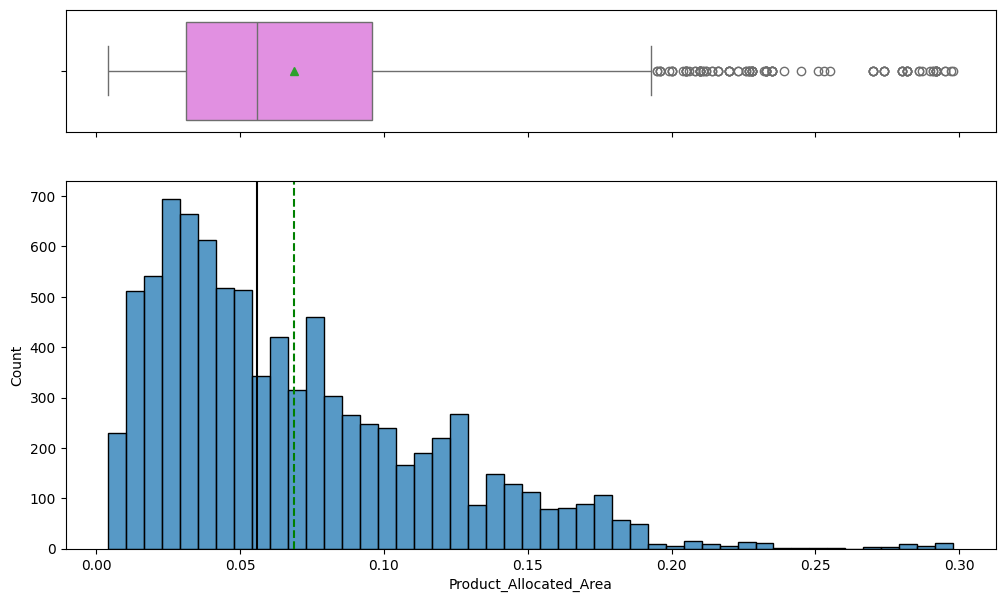

In [ ]:
histogram_boxplot(SuperKart_dataset, "Product_Allocated_Area")

* Display area allocation is right-skewed, with most products receiving small shelf space (0.05–0.10), while a few high-priority products get larger allocations — indicating strategic merchandising.

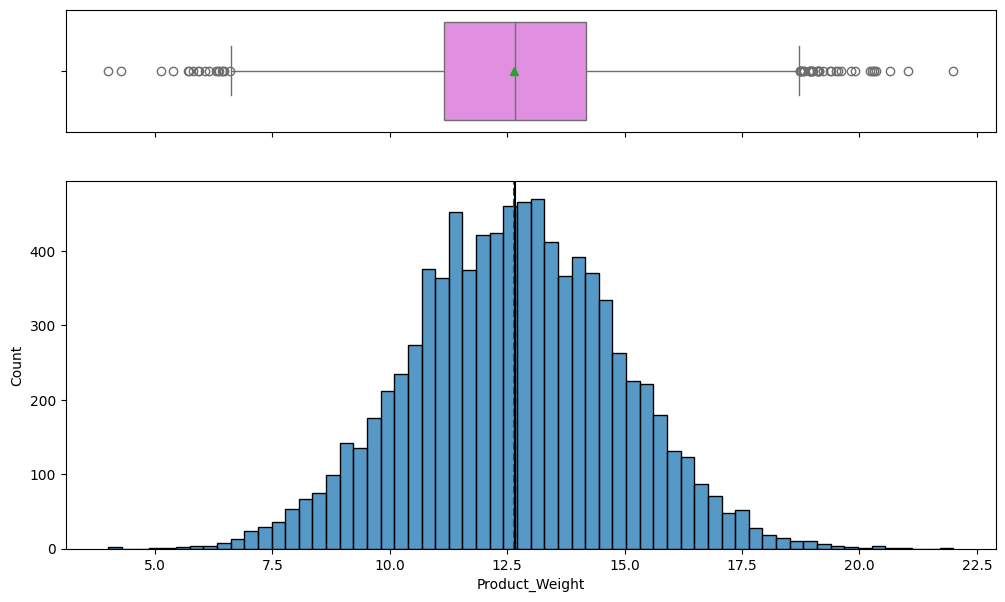

In [ ]:
histogram_boxplot(SuperKart_dataset, "Product_Weight")

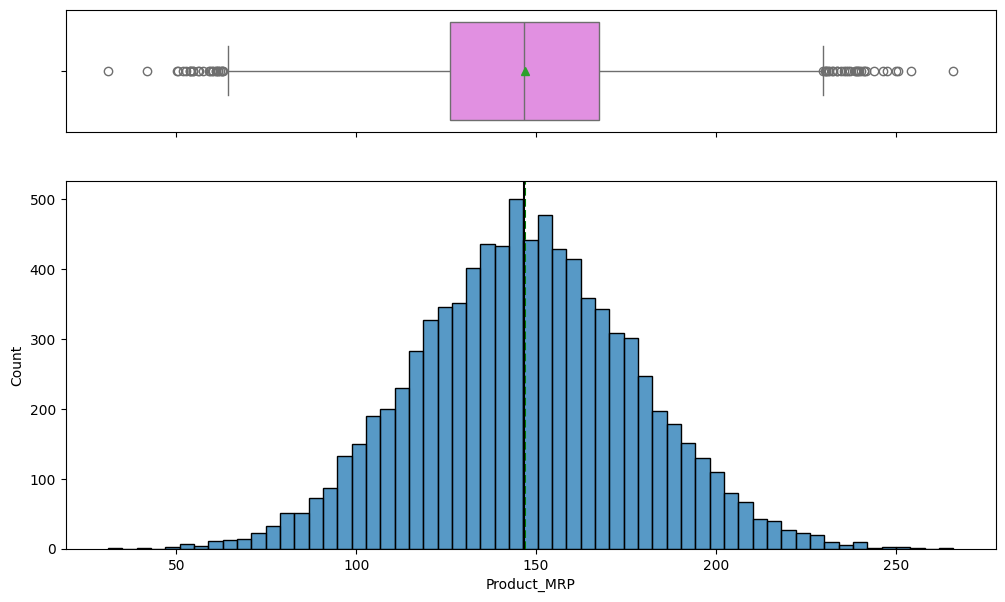

In [ ]:
histogram_boxplot(SuperKart_dataset, "Product_MRP")

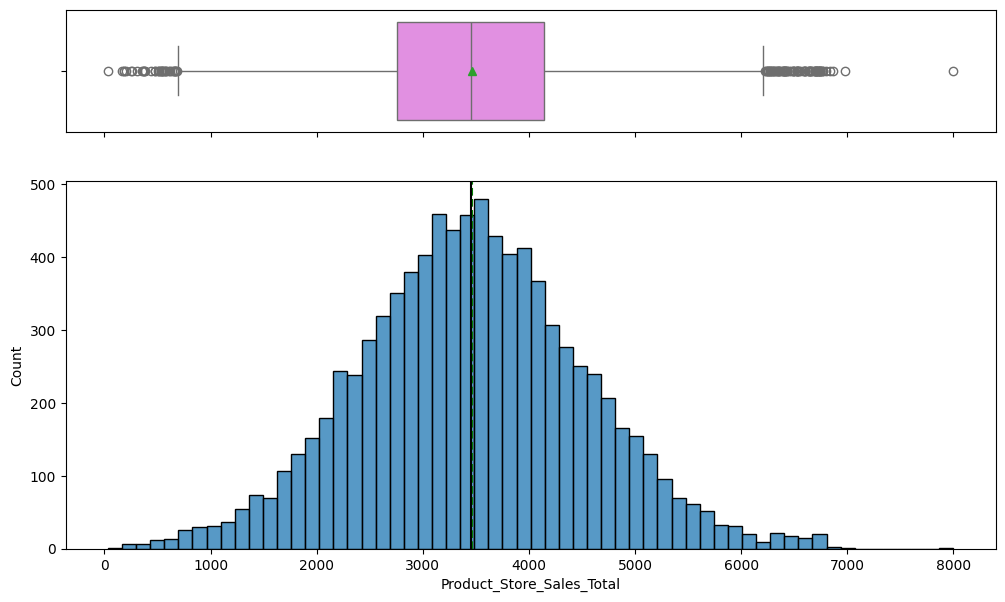

In [ ]:
#distribution of target variable
histogram_boxplot(SuperKart_dataset, "Product_Store_Sales_Total")

* Product Weight, MRP and Stores Sales Total are normally distributed

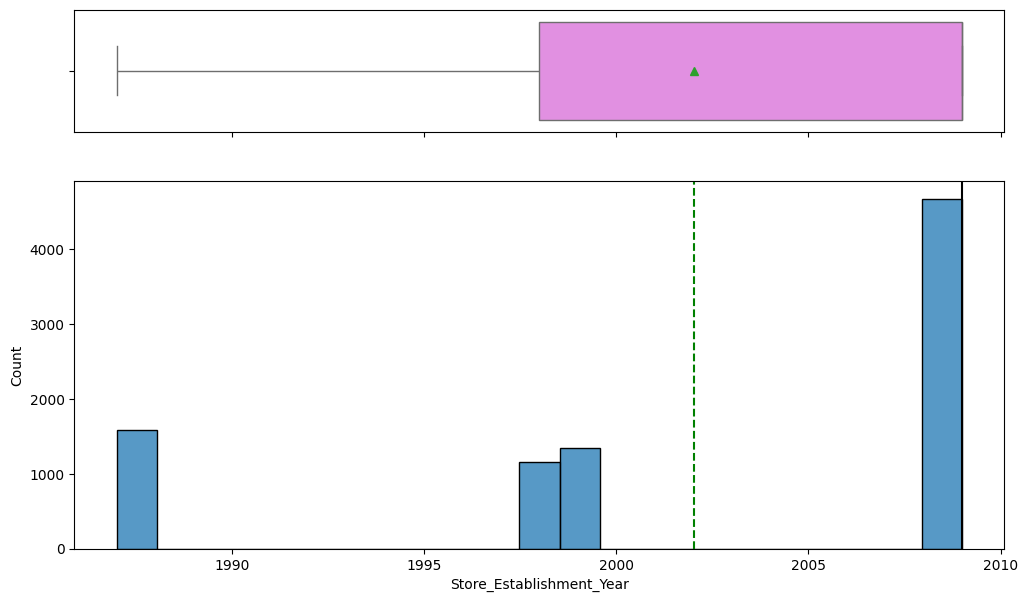

In [ ]:
histogram_boxplot(SuperKart_dataset, "Store_Establishment_Year")

* Store opening are more occured early 1990 and late 2000s

* All the above data shows some outliers. These are relevant in our project

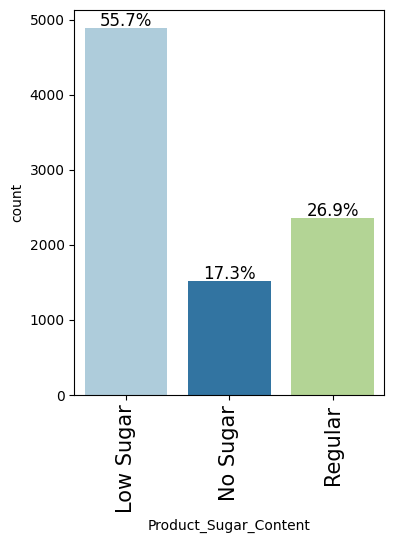

In [ ]:
labeled_barplot(SuperKart_dataset, "Product_Sugar_Content", perc=True)

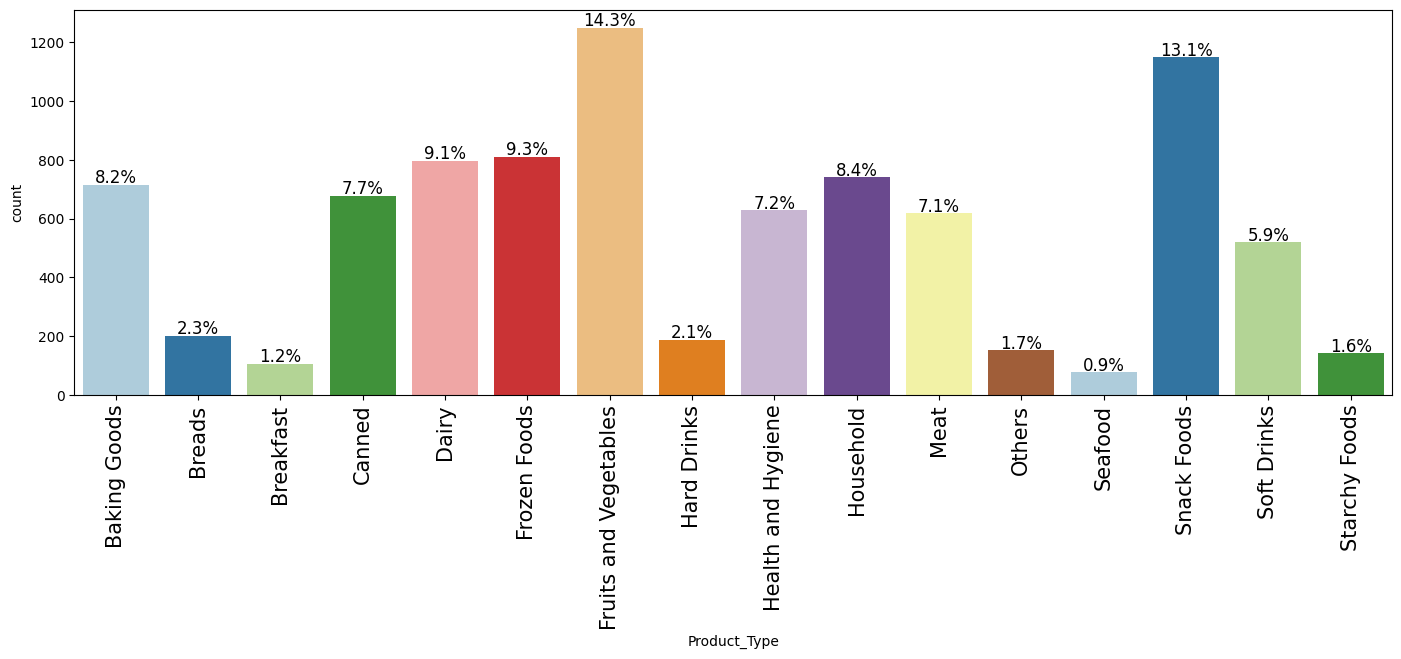

In [ ]:
labeled_barplot(SuperKart_dataset, "Product_Type", perc=True)

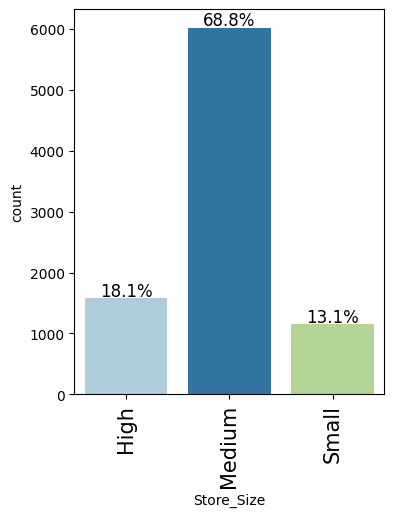

In [ ]:
labeled_barplot(SuperKart_dataset, "Store_Size", perc=True)

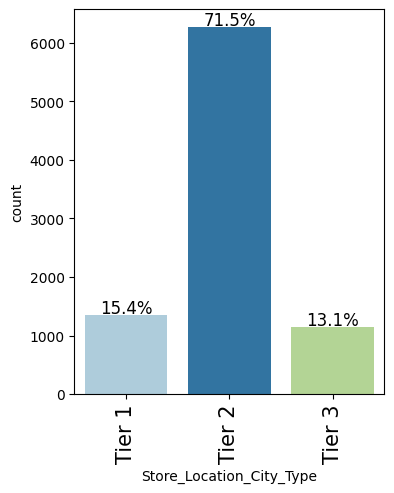

In [ ]:
labeled_barplot(SuperKart_dataset, "Store_Location_City_Type", perc=True)

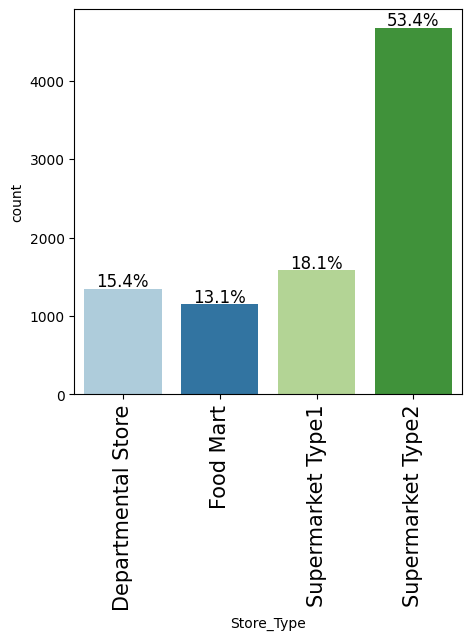

In [ ]:
labeled_barplot(SuperKart_dataset, "Store_Type", perc=True)

* Over half of the product range (55.7%) consists of low-sugar items, reflecting a clear strategic pivot toward health-conscious consumers.

* The inventory maintains a balance between fresh essentials and indulgence; Fruits & Vegetables lead the categories (14.3%), closely followed by Hard Drinks (14.3%) and Snack Foods (13.1%).

* Store OUT004 accounts for a staggering 53.4% of all data records, suggesting either a central operational powerhouse or a significant skew in data reporting.

* SuperKart prioritizes medium-sized outlets, which comprise 68.8% of the network, likely to optimize the balance between overhead costs and customer reach.

* The brand's primary footprint is in Tier 2 cities (71.5% of stores), targeting emerging urban markets with high growth potential and moderate living costs.

* Supermarket Type 2 is the dominant store model (53.4%), serving as the primary touchpoint for customers over Type 1 and Departmental formats.


In [ ]:
# Get the current year
from datetime import datetime
current_year = datetime.now().year
# Calculate store age as of current year
SuperKart_dataset['Store_Age'] = current_year - SuperKart_dataset['Store_Establishment_Year']
# Add new column to Numerical
numerical_columns.append('Store_Age')

In [ ]:
# remove 'Store_Establishment_Year' from numerical columns
numerical_columns.remove('Store_Establishment_Year')

In [ ]:
# remove 'Store_Establishment_Year' from revenue
SuperKart_dataset.drop('Store_Establishment_Year',axis=1,inplace=True)

* Created a new column 'Store Age' instead of 'Store_Establishment_Year'

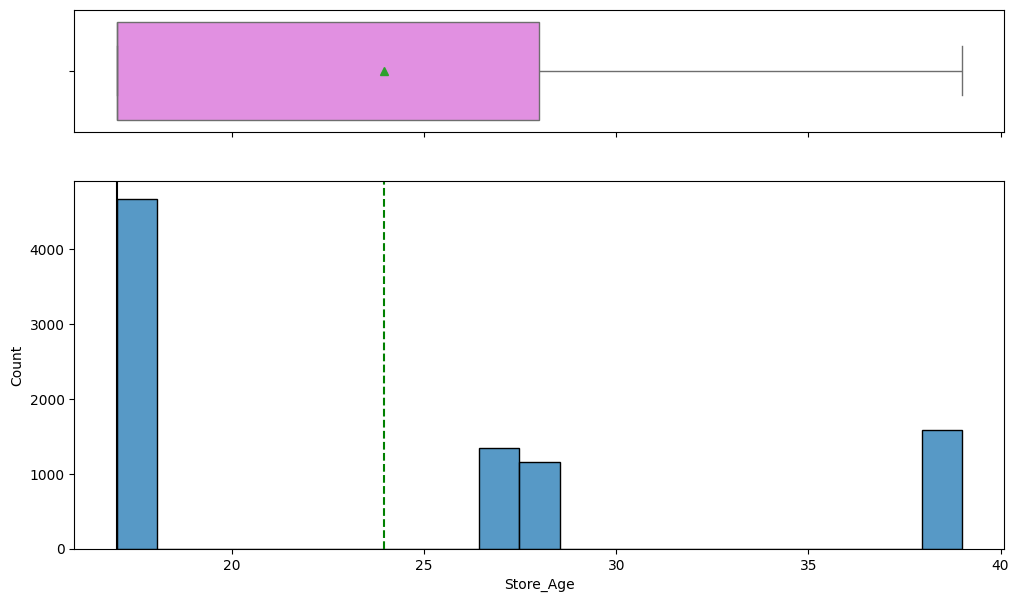

In [ ]:
histogram_boxplot(SuperKart_dataset, "Store_Age")

* More than 4000 stores are established in less than 20 years.
* less than 2000 stores are established in more than 25 years

## Bivariate Analysis

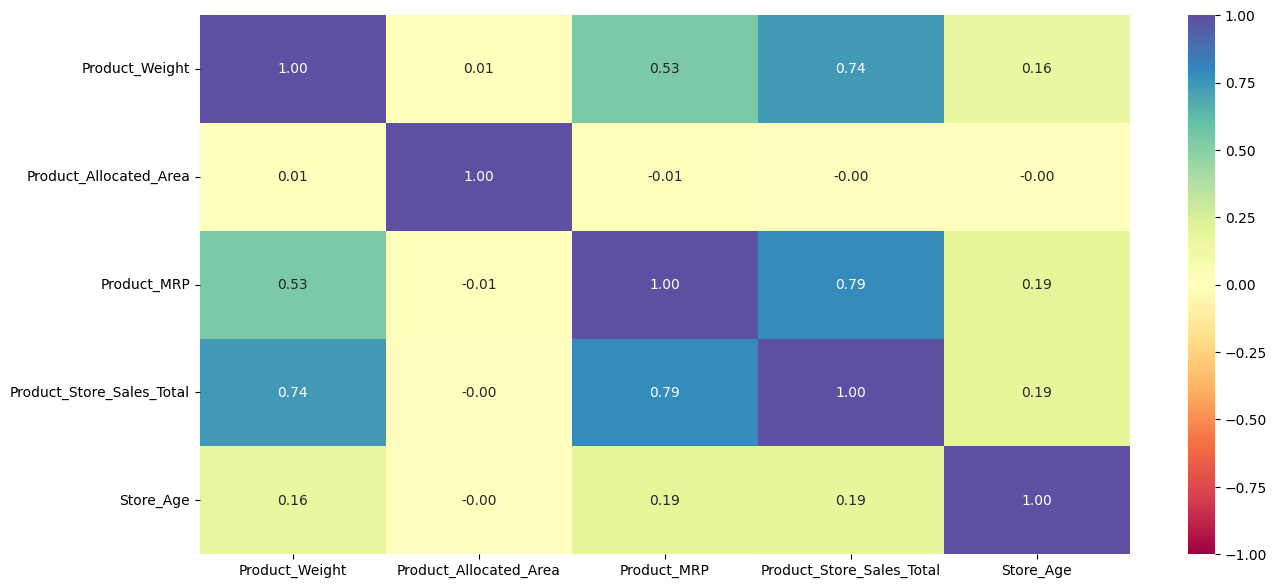

In [ ]:
# Correlation plot
plt.figure(figsize=(15, 7))
sns.heatmap(SuperKart_dataset.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* There is a strong positive correlation between Product_weight and Product_Store_sales_Total.
* Nearly zero correlation among the display allocated
area and Product_Store_sales_Total


<Figure size 1500x1500 with 0 Axes>

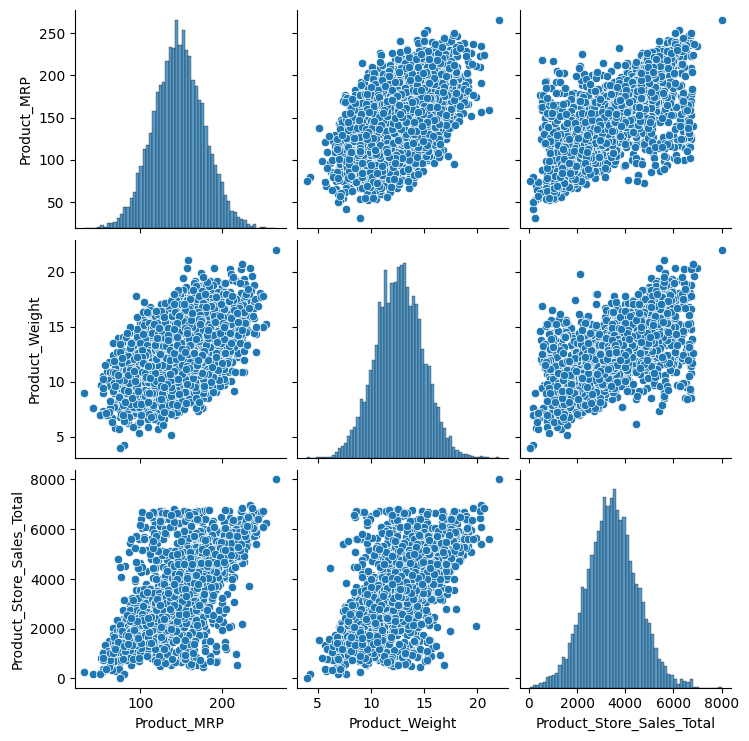

In [ ]:
# Plotting pair plot
#Set the figure size
plt.figure(figsize=(15,15))
# Plot pairwise graphs
sns.pairplot(SuperKart_dataset[['Product_MRP','Product_Weight','Product_Store_Sales_Total']])
plt.show()

* Plot shows the positive correlation of sales revenue with MRP and Product Weight

In [ ]:
SuperKart_dataset.groupby('Product_Type')['Product_Store_Sales_Total'].sum().sort_values(ascending=False)


Product_Type
Fruits and Vegetables    4300833.27
Snack Foods              3988996.95
Dairy                    2811918.04
Frozen Foods             2809980.83
Household                2564740.17
Baking Goods             2452986.00
Canned                   2300082.71
Health and Hygiene       2163707.21
Meat                     2129211.94
Soft Drinks              1797044.72
Breads                    714942.24
Hard Drinks               625814.62
Others                    541496.30
Starchy Foods             518774.45
Breakfast                 362130.41
Seafood                   272404.04
Name: Product_Store_Sales_Total, dtype: float64

* Highest revenue generated by fruits and vegetables and lowest revenue generated by seafood

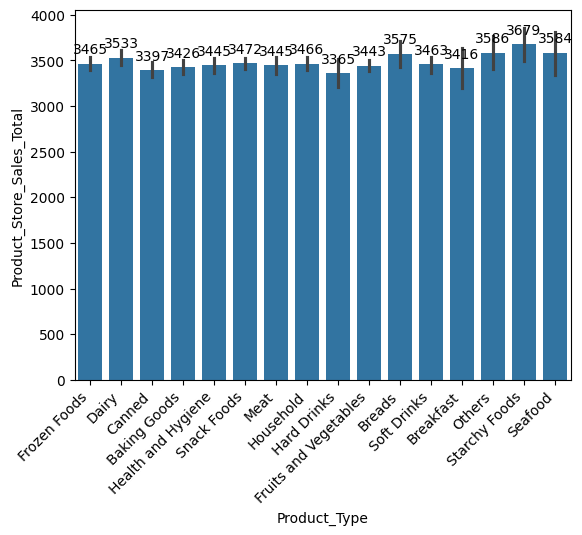

In [ ]:
# Distribution of sales revenue wrt Product Type
ax=sns.barplot(x="Product_Type", y="Product_Store_Sales_Total", data=SuperKart_dataset)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i in ax.patches:
    ax.annotate(f'{i.get_height():.0f}', (i.get_x() + i.get_width() / 2., i.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

* The Starchy food has highest sales and canned food has lowest sales

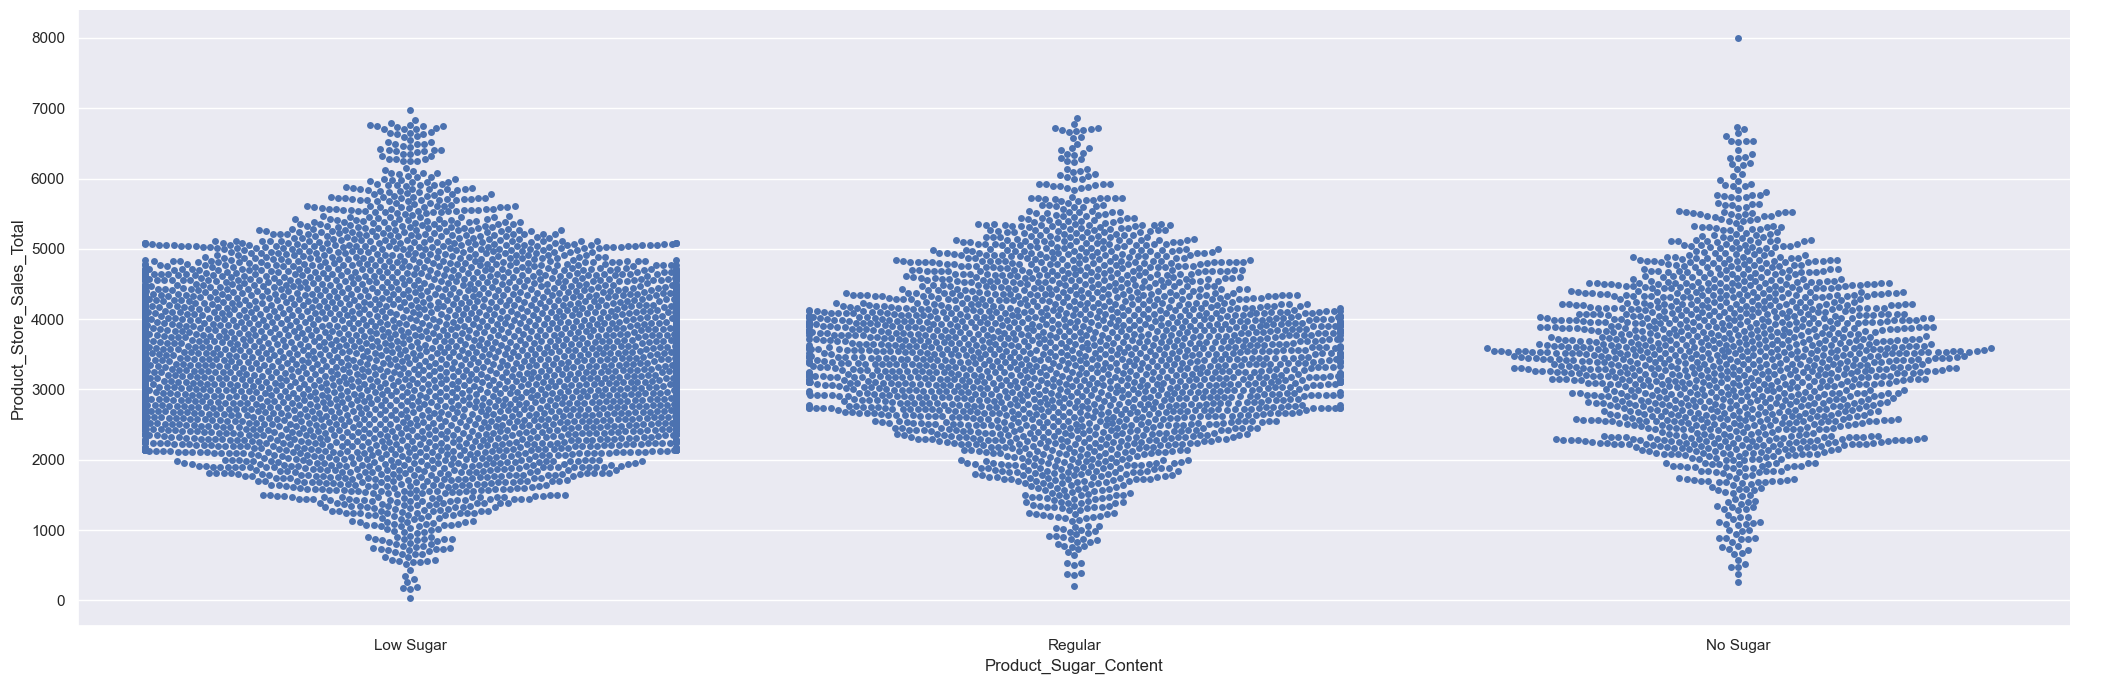

In [ ]:
sns.set(rc={'figure.figsize':(21,7)})
sns.catplot(x="Product_Sugar_Content", y="Product_Store_Sales_Total", kind="swarm", data=SuperKart_dataset, height=7, aspect=3);

In [ ]:
SuperKart_dataset.groupby('Product_Sugar_Content')['Product_Store_Sales_Total'].sum().sort_values(ascending=False)

Product_Sugar_Content
Low Sugar    16823405.80
Regular       8261714.42
No Sugar      5269943.68
Name: Product_Store_Sales_Total, dtype: float64

* The highest revenue genrated for Low Sugar content and lowest revenue genrated by No sugar content

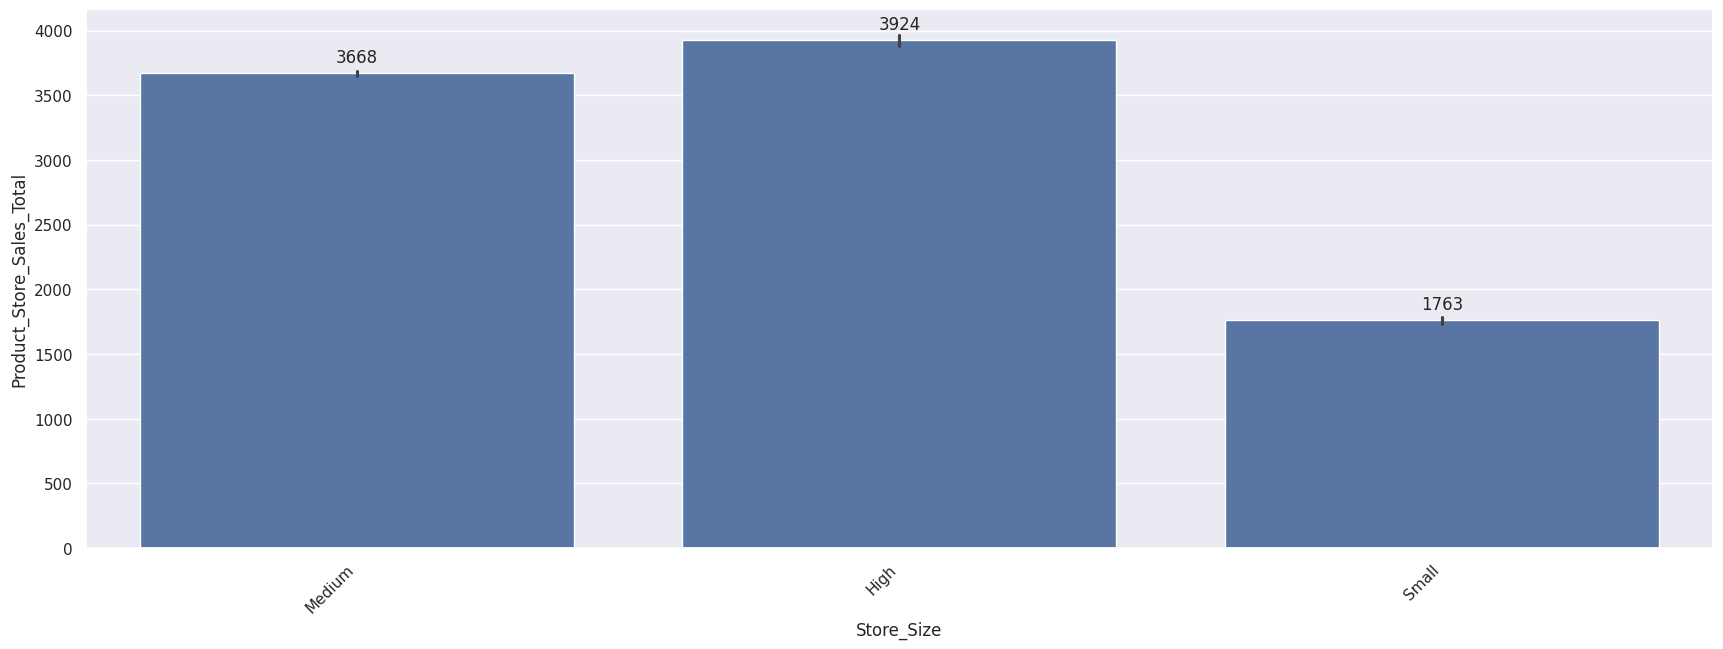

In [ ]:
# distribution of Sales  revenue wrt Sugar Content
ax = sns.barplot(x="Store_Size", y="Product_Store_Sales_Total", data=SuperKart_dataset)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

In [ ]:
SuperKart_dataset.groupby('Store_Size')['Product_Store_Sales_Total'].sum().sort_values(ascending=False)

,Product_Store_Sales_Total
Store_Size,
Medium,22101041.00
High,6223113.18
Small,2030909.72


* Highest revenue genrated by Medium stores

In [ ]:
SuperKart_dataset.groupby('Store_Location_City_Type')['Product_Store_Sales_Total'].sum().sort_values(ascending=False)

,Product_Store_Sales_Total
Store_Location_City_Type,
Tier 2,21650696.61
Tier 1,6673457.57
Tier 3,2030909.72


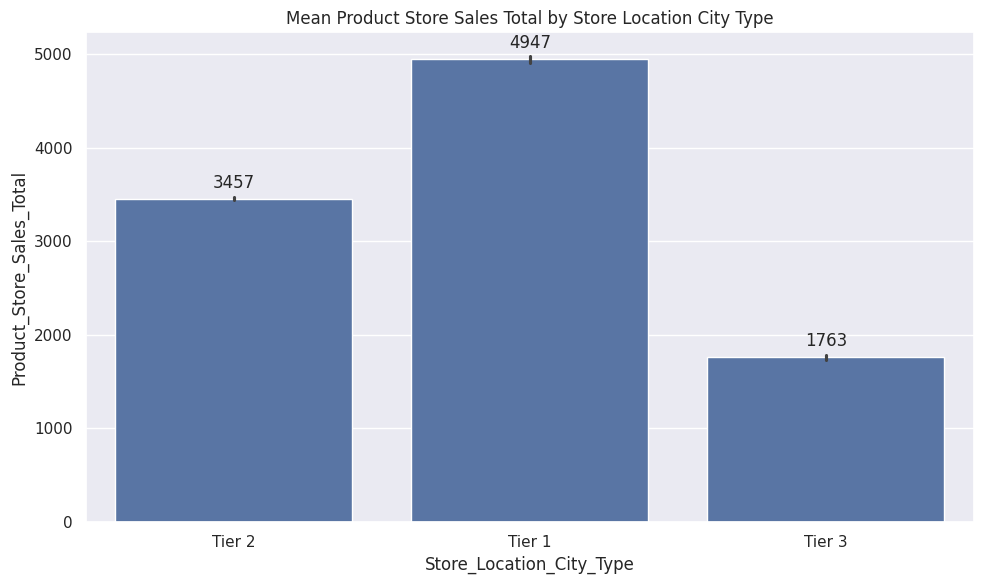

In [ ]:
plt.figure(figsize=(10, 6))
ax_city = sns.barplot(x="Store_Location_City_Type", y="Product_Store_Sales_Total", data=SuperKart_dataset)
ax_city.set_title('Mean Product Store Sales Total by Store Location City Type')
for p in ax_city.patches:
    ax_city.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

* The highest sales is more in Tier2 and the avarage sales is more in Tier1

In [ ]:
print("Total revenue per Store_Type:")
print(SuperKart_dataset.groupby('Store_Type')['Product_Store_Sales_Total'].sum().sort_values(ascending=False))


Total revenue per Store_Type:
Store_Type
Supermarket Type2     15427583.43
Departmental Store     6673457.57
Supermarket Type1      6223113.18
Food Mart              2030909.72
Name: Product_Store_Sales_Total, dtype: float64


* Highest sales happend in Supermarket Type2
* The lowest sales happend in Food Mart

In [ ]:
SuperKart_dataset.groupby('Store_Id')['Product_Store_Sales_Total'].sum().sort_values(ascending=False)

,Product_Store_Sales_Total
Store_Id,
OUT004,15427583.43
OUT003,6673457.57
OUT001,6223113.18
OUT002,2030909.72


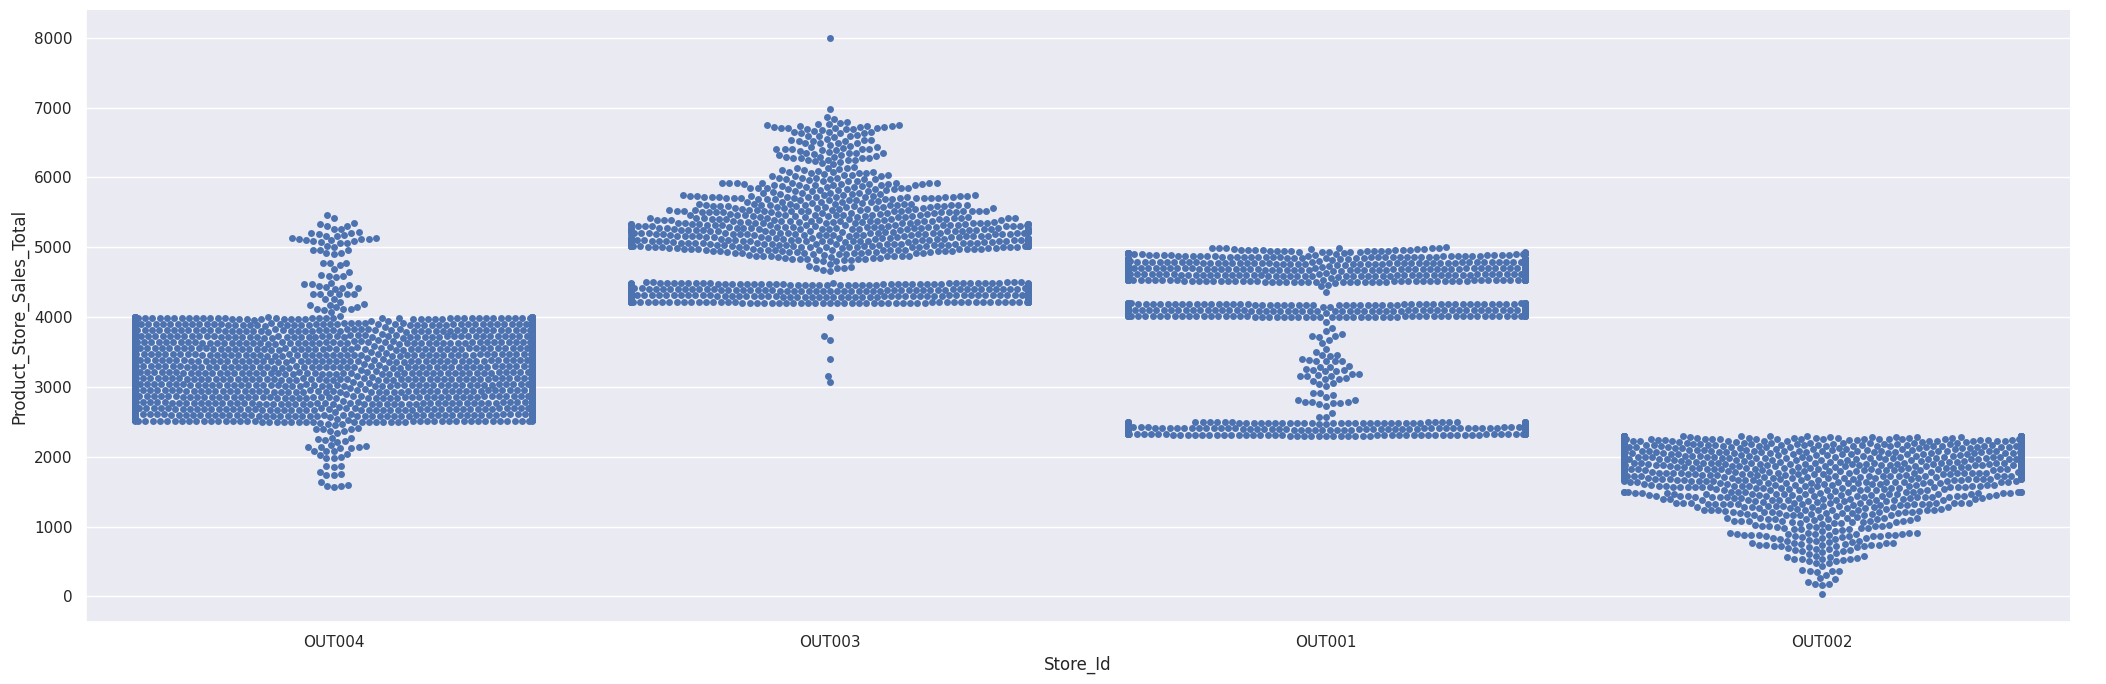

In [ ]:
# Plot relationships between store_id and revenue
sns.set(rc={'figure.figsize':(21,7)})
sns.catplot(x="Store_Id", y="Product_Store_Sales_Total", kind="swarm", data=SuperKart_dataset, height=7, aspect=3);

* Store Id OUT004 has generated highest revenue than others.
* Stire Id OUT003 has the highest revenue, which seems like an exceptional occurence.

# **Data Preprocessing**

In [ ]:

# Define the target variable for the classification task
target = 'Product_Store_Sales_Total'

# Define predictor matrix (X) using selected numeric and categorical features
X = SuperKart_dataset.drop('Product_Store_Sales_Total',axis=1)

# Define target variable
y = SuperKart_dataset[target]



In [ ]:

# Split the dataset into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [ ]:
# reset the indexes to check the prediction
ytrain = ytrain.reset_index(drop=True)
ytest = ytest.reset_index(drop=True)

In [ ]:
print(numerical_columns)
print(categorical_columns)

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Product_Store_Sales_Total', 'Store_Age']
['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


In [ ]:
# Before creating the transformer, ensure they aren't None
# Remove the target from the list of columns to be scaled
numeric_features = [col for col in numerical_columns if col != 'Product_Store_Sales_Total']

categorical_features = categorical_columns
# Create a preprocessing pipeline for numerical and categorical features
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),  # Scale numeric features to have mean equal to 0 and standard deviation equal to 1
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Encode categorical features as one-hot vectors
)


 * preprocessor make_column_transformer
   * Standardizes numerical features (StandardScaler)
      * Scales numerical columns to have zero mean and unit variance.  
      *  This ensures that numerical features with different ranges are transformed to the same scale, improving model performance.  

   * One-hot encodes categorical features (e.g., OneHotEncoder)  
* Prepares the data for ML models    


# **Model Building**

## Define functions for Model Evaluation

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [ ]:
##  Function to calculate r2_score and RMSE on train and test data
def get_model_score(model, flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    pred_train = model.predict(Xtrain)
    pred_test = model.predict(Xtest)

    train_r2=r2_score(ytrain,pred_train)
    test_r2=r2_score(ytest,pred_test)
    train_rmse=np.sqrt(mean_squared_error(ytrain,pred_train))
    test_rmse=np.sqrt(mean_squared_error(ytest,pred_test))

    #Adding all scores in the list
    score_list.extend((train_r2,test_r2,train_rmse,test_rmse))

    # If the flag is set to True then only the following print statements will be dispayed, the default value is True
    if flag==True:
        print("R-sqaure on training set : ",r2_score(ytrain,pred_train))
        print("R-square on test set : ",r2_score(ytest,pred_test))
        print("RMSE on training set : ",np.sqrt(mean_squared_error(ytrain,pred_train)))
        print("RMSE on test set : ",np.sqrt(mean_squared_error(ytest,pred_test)))

    # returning the list with train and test scores
    return score_list

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

# **Creating Model**
  

## 1. Random Forest

In [ ]:
model_rf_estimator=RandomForestRegressor(random_state=48)

In [ ]:
# Create a machine learning pipeline with preprocessing and model training steps
model_rf_pipeline = make_pipeline(
    preprocessor,  # Preprocesses numerical and categorical features
    model_rf_estimator      # Random Forest Regressor for model training
)

* make_pipeline is a function from scikit-learn that creates a sequential pipeline for data preprocessing and model training.
* It ensures that all necessary transformations are applied before passing the data to the model.

# **Model Training**

In [ ]:
# Train the model pipeline on the training data
model_rf_pipeline.fit(Xtrain, ytrain)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=48))])

In [ ]:
# make predictions on the training data
y_pred_rf_train=model_rf_pipeline.predict(Xtrain)
# Make predictions on the test data
y_pred_rf_test=model_rf_pipeline.predict(Xtest)

In [ ]:
#Check the prediction on training set
print("Predicted value  for 1300th row in the training set",y_pred_rf_train[0])
print("Actual value  for 1300th row in the training set",ytrain[0])

Predicted value  for 1300th row in the training set 3882.2052000000012
Actual value  for 1300th row in the training set 3882.69


In [ ]:
#Check the prediction on training set
print("Predicted value  for 1300th row in the test set",y_pred_rf_test[0])
print("Actual value  for 1300th row in the test set",ytest[0])

Predicted value  for 1300th row in the test set 3309.132099999998
Actual value  for 1300th row in the test set 3396.37


## Model Perfrmance Evaluation

In [ ]:
model_perform_rf_train=model_performance_regression(model_rf_pipeline, Xtrain, ytrain)
model_perform_rf_train

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,108.069081,40.457285,0.989701,0.989687,0.015044


* The model exhibits a near-perfect fit with an $R^2$ of 0.9897, effectively capturing 98.97% of the underlying variance.
* Coupled with a low MAPE of 1.5%, these metrics confirm the model's high degree of predictive accuracy and reliability."


In [ ]:
model_perform_rf_test=model_performance_regression(model_rf_pipeline, Xtest, ytest)
model_perform_rf_test

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,286.765586,110.410084,0.927929,0.927515,0.039531


* This model demonstrates excellent predictive accuracy and a strong fit, as evidenced by the high $R^2$ and $R^2_{adj}$ values of approximately 0.928. With a very low MAPE (3.95%) and relatively small error metrics (RMSE/MAE), the model is highly reliable for forecasting with minimal deviation from actual values.

## **Model Performance Improvement - Hyperparameter Tuning**

* Some of the important hyperparameters to eune random forest regressor are:

   * n_estimators: The number of trees in the forest, default = 100

   * max_features: The number of features to consider when looking for the best split
   * max_depth: Controls the maximum depth (number of levels/splits) that each decision tree in the Random Forest can grow


In [ ]:
# Choose the type of Regressor model.
model_rf_tuned = RandomForestRegressor(random_state=48)

# Create a machine learning pipeline with preprocessing and model training steps
model_rf_tuned_pipeline = make_pipeline(
    preprocessor,  # Preprocesses numerical and categorical features
    model_rf_tuned      # Random Forest Regressor for model training
)

# Grid of parameters to choose from
parameters = {
                'randomforestregressor__max_depth':[4, 6, 8, 10, None],
                'randomforestregressor__max_features': ['sqrt','log2',None],
                'randomforestregressor__n_estimators': [80, 90, 100, 110, 120]
}

# Type of scoring used to compare parameter combinations
from sklearn import metrics
scorer = metrics.make_scorer(metrics.r2_score)


# Run the grid search
grid_rf_obj = GridSearchCV(model_rf_tuned_pipeline, parameters, scoring=scorer,cv=5)
grid_rf_obj = grid_rf_obj.fit(Xtrain, ytrain)

# Set the clf to the best combination of parameters
rf_tuned = grid_rf_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(Xtrain, ytrain)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=10, max_features=None,
                                       n_estimators=120, random_state=48))])

In [ ]:
# Get the best parameters and best estimator of Random Forest Tuned Regressor
best_rf_params=grid_rf_obj.best_params_
best_rf_estimator=grid_rf_obj.best_params_

print("Best parameters of Random Forest Tuned pipeline:",best_rf_params)


Best parameters of Random Forest Tuned pipeline: {'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': None, 'randomforestregressor__n_estimators': 120}


## Model Perfrmance Evaluation after hyper Tuning

In [ ]:
model_perform_rfTuned_train=model_performance_regression(rf_tuned, Xtrain, ytrain)
model_perform_rfTuned_train

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,188.10257,77.791388,0.9688,0.968755,0.027227


* The model demonstrates exceptional performance on the training data with an $R^2$ of 0.9688 and a very low MAPE of 2.72%, indicating it has successfully captured the underlying patterns and variance of the dataset

In [ ]:
model_perform_rfTuned_test=model_performance_regression(rf_tuned, Xtest, ytest)
model_perform_rfTuned_test

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,281.221195,115.25389,0.930689,0.930291,0.041124


* The testing results remain strong with an $R^2$ of 0.9308, though the slight increase in error metrics (RMSE and MAE) compared to training suggests a minor, yet manageable, degree of overfitting.

## 2. XGBoost

In [ ]:
# Initialize an XGBoost Regressor
model_xgb = XGBRegressor(random_state=48)

In [ ]:
# Create a machine learning pipeline with preprocessing and model training steps
model_xgb_pipeline = make_pipeline(
    preprocessor,  # Preprocesses numerical and categorical features
    model_xgb      # XGBoost Regresser for model training
)

# **Model Training**

In [ ]:
# Train the model pipeline on the training data
model_xgb_pipeline.fit(Xtrain, ytrain)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('xgbregre...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=48, ...))])

In [ ]:
# Make predictions on the training data
y_pred_xgb_train = model_xgb_pipeline.predict(Xtrain)

# Make predictions on the test data
y_pred_xgb_test = model_xgb_pipeline.predict(Xtest)

In [ ]:
# Check the prediction on training set
print("Predicted value  for 1300th row in the training set",y_pred_xgb_train[0])
print("Actual value  for 1300th row in the training set",ytrain[0])

Predicted value  for 1300th row in the training set 3907.8694
Actual value  for 1300th row in the training set 3882.69


In [ ]:
# Check the prediction on training set
print("Predicted value  for 1300th row in the testing set",y_pred_xgb_test[0])
print("Actual value  for 1300th row in the testing set",ytest[0])

Predicted value  for 1300th row in the testing set 3393.3933
Actual value  for 1300th row in the testing set 3396.37


## Model Perfrmance Evaluation of XGBoost Regressor

In [ ]:
model_perform_xgb_train=model_performance_regression(model_xgb_pipeline, Xtrain, ytrain)
model_perform_xgb_train

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,132.873337,62.735069,0.984431,0.984409,0.022233


* The model shows an exceptional fit on the training data with an $R^2$ of 0.984, suggesting it has successfully captured nearly all the underlying patterns and variance in the dataset.

In [ ]:
model_perform_xgb_test=model_performance_regression(model_xgb_pipeline, Xtest, ytest)
model_perform_xgb_test

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.267823,137.549807,0.915632,0.915147,0.051029


* While the testing $R^2$ remains strong at 0.915, there is a noticeable performance drop and a significant increase in error (RMSE) compared to training, which indicates mild overfitting.

## Model Performance Improvement - Hyperparameter Tuning of XGBoost Regressor

* Some of the important hyperparameters to tune for XGBRegressor are:

    * n_estimators: Number of boosting trees to build — more trees increase model capacity but risk overfitting if not regularized.
    * subsample: Fraction of training samples randomly selected for each tree, introducing bagging to reduce overfitting.
    * gamma: Minimum loss reduction required to make a split — higher values enforce stricter splitting criteria for stronger regularization.
    * colsample_bytree: Fraction of features randomly sampled for each tree, reducing correlation between trees and improving generalization.
    * colsample_bylevel: Fraction of features randomly sampled at each split level within a tree, adding finer-grained feature randomness for regularization.

In [ ]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=48)

# Grid of parameters to choose from
parameters = {'xgbregressor__n_estimators': [80, 90, 100, 110, 120],
              'xgbregressor__subsample':[0.7, 0.8, 0.9, 1],
              'xgbregressor__gamma':[0, 1, 3, 5],
              'xgbregressor__colsample_bytree':[0.7, 0.8, 0.9, 1],
              'xgbregressor__colsample_bylevel':[0.7, 0.8, 0.9, 1]
              }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)
# Make a pipeline
model_xgb_tuned_pipeline = make_pipeline(
    preprocessor,  # Preprocesses numerical and categorical features
    xgb_tuned      #Random Forest Regressor for model training
)
# Run the grid search
grid_obj_xgb_tuned = GridSearchCV(model_xgb_tuned_pipeline, parameters, scoring=scorer,cv=5)
grid_obj_xgb_tuned = grid_obj_xgb_tuned.fit(Xtrain, ytrain)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj_xgb_tuned.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(Xtrain, ytrain)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('xgbregre...
                              feature_types=None, gamma=1, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=80, n_jobs=None,
                              num_parallel_tree=None, random_state=48, ...))])

In [ ]:
# Get the best parameters and best estimator (which is the tuned pipeline itself)
best_params_xgb = grid_obj_xgb_tuned.best_params_
best_estimator_xgb = grid_obj_xgb_tuned.best_estimator_

print("Best parameters for XGBRegressor tuned pipeline:", best_params_xgb)


Best parameters for XGBRegressor tuned pipeline: {'xgbregressor__colsample_bylevel': 0.8, 'xgbregressor__colsample_bytree': 0.8, 'xgbregressor__gamma': 1, 'xgbregressor__n_estimators': 80, 'xgbregressor__subsample': 1}


## Model Perfrmance Evaluation after tuning XGBRegressor

In [ ]:
model_perform_xgbTuned_train=model_performance_regression(xgb_tuned, Xtrain, ytrain)
model_perform_xgbTuned_train

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,160.187613,73.606369,0.977373,0.977341,0.025587


* The model demonstrates exceptional fit during training, with an $R^2$ of 0.977 and a very low MAPE of 2.56%, indicating it has successfully captured the underlying patterns in the data with high precision.

In [ ]:
model_perform_xgbTuned_test=model_performance_regression(xgb_tuned, Xtest, ytest)
model_perform_xgbTuned_test

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,296.918635,134.540821,0.922735,0.922292,0.048706


* While the testing error naturally increases, the model maintains strong generalizability with an $R^2$ of 0.922 and a MAPE of 4.87%, suggesting it remains reliable when predicting unseen data without significant overfitting.

## Model Performance Comparison, Final Model Selection, and Serialization

## Model Performance Comparison

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [ model_perform_rf_train.T,model_perform_rfTuned_train.T,model_perform_xgb_train.T,model_perform_xgbTuned_train.T],
    axis=1,
)

models_train_comp_df.columns = [

    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGB",
    "XGB Tuned",

]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGB,XGB Tuned
RMSE,108.069081,188.102570,132.873337,160.187613
MAE,40.457285,77.791388,62.735069,73.606369
R-squared,0.989701,0.968800,0.984431,0.977373
Adj. R-squared,0.989687,0.968755,0.984409,0.977341
MAPE,0.015044,0.027227,0.022233,0.025587


1. Random Forest (Base Model)
This model is the strongest performer across all evaluation metrics. With an R-squared value of 0.9897, it explains nearly 99% of the variance in the data. It also achieves the lowest prediction errors, with an RMSE of 108.07 and MAE of 40.46, indicating predictions that are very close to the true values. Additionally, the MAPE of 1.5% is exceptionally low, demonstrating outstanding relative accuracy.

2. Random Forest (Tuned Model)
Unexpectedly, hyperparameter tuning led to a notable decline in performance. The RMSE increased from 108 to 188, suggesting that the tuning process may have constrained the model too heavily. This outcome can occur when the search space is overly restrictive or when the default parameters are already well-aligned with the dataset.

3. XGBoost (Base Model)
The base XGBoost model ranks as the second-best performer. It delivers strong results with an R-squared of 0.984, though it falls short of the base Random Forest in terms of prediction error, with an RMSE of 132.87 compared to 108.07. While highly competitive, it requires further optimization to surpass the Random Forest model.

4. XGBoost (Tuned Model)
As observed with Random Forest, tuning the XGBoost model resulted in increased error. The RMSE rose from 132.87 to 160.19, indicating that the tuning process may have over-regularized the model or failed to identify optimal hyperparameter combinations.

In [ ]:
# Testing performance comparison
models_test_comp_df = pd.concat(
    [ model_perform_rf_test.T,model_perform_rfTuned_test.T,model_perform_xgb_test.T,model_perform_xgbTuned_test.T],
    axis=1,
)

models_test_comp_df.columns = [

    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGB",
    "XGB Tuned",

]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGB,XGB Tuned
RMSE,286.765586,281.221195,310.267823,296.918635
MAE,110.410084,115.253890,137.549807,134.540821
R-squared,0.927929,0.930689,0.915632,0.922735
Adj. R-squared,0.927515,0.930291,0.915147,0.922292
MAPE,0.039531,0.041124,0.051029,0.048706


* Testing Performance Review

* During the testing phase, performance differences between the models narrow considerably, and the earlier tuning trend reverses. Although the base Random Forest model dominated the training results, the tuned Random Forest emerges as the most reliable performer on unseen data.

1. Random Forest (Tuned)

   * This model demonstrates the strongest overall generalization performance.

   * Accuracy: It achieves the highest R-squared value (0.9307), indicating superior explanatory power on the test set.

   * Large Error Control: With the lowest RMSE (281.22), the tuned model is less sensitive to extreme prediction errors, suggesting greater stability and fewer large deviations.

2. Random Forest (Base Model)

   * The base Random Forest remains highly competitive and excels in average-error metrics.

   * It records the lowest MAE (110.41) and MAPE (0.0395), indicating slightly better performance for typical predictions.

   * higher RMSE compared to the tuned version suggests a greater presence of occasional large prediction errors.

3. XGBoost (Base and Tuned Models)

   * Both XGBoost variants underperform relative to the Random Forest models in this testing scenario.

   * Hyperparameter tuning improves XGBoost’s R-squared from 0.9156 to 0.9227, but

   * Both versions still exhibit higher MAE and RMSE, indicating larger average errors and increased sensitivity to outliers.

### Best Model for Deployment

   * The tuned Random Forest is the most suitable model for deployment.
   * The Random Forest Tuned model is the superior performer because it generalizes best to new data, outperforming both XGBoost variants and its own baseline in error reduction (RMSE).
   *  By tuning the hyperparameters, the model successfully balanced its complexity, leading to the most accurate and stable predictions on the test suite.
   * The baseline RF has a slightly lower MAE, the RMSE is often prioritized in these scenarios because it penalizes larger errors more heavily.
   * Random Forest Tuned provides the most consistent performance

## Final Model- Random Forest Tuned

In [ ]:
# Extract the best parameters found by your GridSearch
best_params = grid_rf_obj.best_params_
print("Best Params found:", best_params)
#  Get the best estimator (the pipeline)
rf_tuned = grid_rf_obj.best_estimator_
# fit the model
rf_tuned.fit(Xtrain, ytrain)

Best Params found: {'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': None, 'randomforestregressor__n_estimators': 120}


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=10, max_features=None,
                                       n_estimators=120, random_state=48))])

## **Serialization**

In [ ]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [ ]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/sales_prediction_model_v1_0.joblib"

# Serialize (Save) the fitted model

joblib.dump(rf_tuned, saved_model_path)

['backend_files/sales_prediction_model_v1_0.joblib']

* This code is used to save a trained machine learning model pipeline using `joblib`, which is a library for efficient object serialization in Python.
* This approach ensures that the model pipeline, including preprocessing steps and the trained model, is preserved for later use.

In [ ]:
# Load the saved model pipeline from the file
saved_model = joblib.load(saved_model_path)

In [ ]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=10, max_features=None,
                                       n_estimators=120, random_state=48))])

In [ ]:
# Prediction on test data
saved_model.predict(Xtest)

array([3374.50654448, 3351.08175923, 2402.59696013, ..., 4120.22774465,
       2858.5285974 , 4434.36278299])

* Retrieves the array of predictions

# **Deployment - Backend**

* Prepare and deploy backend files in huggingface

## Flask Web Framework


Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or business logic
- Serve HTML templates, form inputs, and JSON data

This API allows any application (like a dashboard, CRM, or mobile app) to send SuperKart data and get back a prediction of next quarterly sales

In [ ]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [ ]:
%%writefile backend_files/app.py
import joblib
import pandas as pd
from flask import Flask, request, jsonify
from datetime import datetime

# Initialize Flask app with a name
app = Flask("Superkart Sales Revenue Predictor")

# Load the trained churn prediction model
model = joblib.load("sales_prediction_model_v1_0.joblib")

# Define a route for the home page
@app.get('/')
def home():
    return "Welcome to the SuperKart Retail Sales Revenue Prediction API"

# Define an endpoint to predict the sale revenue of single product
@app.post('/v1/salesrevenue')
def predict_revenue():
    revenue_data = request.get_json()
    input_df = pd.DataFrame([revenue_data])

    current_year = datetime.now().year
    # Convert to numeric to ensure calculation works
    est_year = int(input_df['Store_Establishment_Year'].iloc[0])
    store_age = current_year - est_year

    # Extract single values using .iloc[0] to avoid 'unhashable type: Series'
    sample = {
        'Product_Weight': input_df['Product_Weight'].iloc[0],
        'Product_Allocated_Area': input_df['Product_Allocated_Area'].iloc[0],
        'Product_MRP': input_df['Product_MRP'].iloc[0],
        'Store_Age': store_age,
        'Product_Sugar_Content': input_df['Product_Sugar_Content'].iloc[0],
        'Product_Type': input_df['Product_Type'].iloc[0],
        'Store_Id': input_df['Store_Id'].iloc[0],
        'Store_Size': input_df['Store_Size'].iloc[0],
        'Store_Location_City_Type': input_df['Store_Location_City_Type'].iloc[0],
        'Store_Type': input_df['Store_Type'].iloc[0]
    }

    # Convert the dictionary into a 1-row DataFrame for the model
    input_datas = pd.DataFrame([sample])

    # Make prediction
    prediction = model.predict(input_datas).tolist()[0]

    return jsonify({'Predicted_Revenue': round(prediction, 2)})
# Define an endpoint to predict revenue for a batch of products
@app.post('/v1/revenuebatch')
def predict_revenue_batch():
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the file into a DataFrame
    input_data = pd.read_csv(file)

    # Find Store age
    current_year = datetime.now().year
    input_data['Store_Age'] = current_year - input_data['Store_Establishment_Year']

    # Make predictions for the batch data
    predictions = model.predict(input_data).tolist()

    # Return the predictions as a JSON response
    return jsonify({'Predictions': [round(p, 2) for p in predictions]})

# Run the Flask app in debug mode
if __name__ == '__main__':
    app.run(debug=True)

Overwriting backend_files/app.py


## Dependencies File

In [ ]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2

Overwriting backend_files/requirements.txt


## Dockerfile

In [ ]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:app"]

Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [ ]:
import getpass

# This prompts the user for input and hides what they type
access_key = getpass.getpass("Enter your access token: ")
# abc = getpass.getpass("Enter your access token: ")

Enter your access token: ··········


## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

access_key = access_key  # Your Hugging Face token created from access keys in write mode
repo_id = "Neethu-Sathyan/BackendSuperKart"  # Your Hugging Face space id with the desired name

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# # Create the repository if it does not exist
# api.create_repo(repo_id=repo_id, repo_type="space", exist_ok=True, space_sdk='docker')

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="./backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space" # Hugging face repo type "space"

)

Uploading...:   0%|          | 0.00/8.82M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/spaces/Neethu-Sathyan/BackendSuperKart/commit/3218b3f42a8d7d4c699799d45c72b6a4a31bcab8', commit_message='Upload folder using huggingface_hub', commit_description='', oid='3218b3f42a8d7d4c699799d45c72b6a4a31bcab8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/Neethu-Sathyan/BackendSuperKart', endpoint='https://huggingface.co', repo_type='space', repo_id='Neethu-Sathyan/BackendSuperKart'), pr_revision=None, pr_num=None)

# **Deployment - Frontend**

* Create a Streamlit space on Hugging Face

## Streamlit for Interactive UI

In [ ]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests
from datetime import datetime

# Streamlit UI for SuperKart Sales Revenue Prediction
st.title("SuperKart Sales Revenue Prediction App")
st.write("Forecasts sales revenue for products based on their details and store characteristics.")

# Collect user input based on dataset columns
st.subheader("Product Details")
product_weight = st.number_input("Product Weight", min_value=0.0, value=12.0, step=0.1)
product_sugar_content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
product_allocated_area = st.number_input("Product Allocated Area", min_value=0.0, max_value=1.0, value=0.05, step=0.01)
product_mrp = st.number_input("Product MRP (Max Retail Price)", min_value=0.0, value=150.0, step=0.1)
product_type = st.selectbox("Product Type", [
    "Fruits and Vegetables", "Snack Foods", "Frozen Foods", "Dairy", "Household",
    "Baking Goods", "Canned", "Health and Hygiene", "Meat", "Soft Drinks",
    "Breads", "Hard Drinks", "Others", "Starchy Foods", "Breakfast", "Seafood"
])

st.subheader("Store Details")
store_id = st.selectbox("Store ID", ["OUT001", "OUT002", "OUT003", "OUT004"])
store_establishment_year = st.number_input("Store Establishment Year", min_value=1900, max_value=datetime.now().year, value=1998, step=1)
store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
store_location_city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
store_type = st.selectbox("Store Type", ["Departmental Store", "Supermarket Type 1", "Supermarket Type 2", "Food Mart"])


# Prepare data for prediction
revenue_data = {
    'Product_Weight': product_weight,
    'Product_Sugar_Content': product_sugar_content,
    'Product_Allocated_Area': product_allocated_area,
    'Product_MRP': product_mrp,
    'Product_Type': product_type,
    'Store_Id': store_id,
    'Store_Establishment_Year': store_establishment_year, # Keep for backend calculation
    'Store_Size': store_size,
    'Store_Location_City_Type': store_location_city_type,
    'Store_Type': store_type,

}


if st.button("Predict Revenue", type='primary'):
    # Update the API endpoint to the new backend service
    response = requests.post("https://neethu-sathyan-backendsuperkart.hf.space/v1/salesrevenue", json=revenue_data)    # Replace with your actual Hugging Face backend URL
    if response.status_code == 200:
        result = response.json()
        predicted_revenue = result["Predicted_Revenue"]
        st.success(f"Predicted Sales Revenue: ₹{predicted_revenue:,.2f}")
    else:
        st.error(f"Error in API request: {response.status_code} - {response.text}")

# Batch Prediction
st.subheader("Batch Prediction (Upload CSV)")

file = st.file_uploader("Upload CSV file (ensure it matches model features)", type=["csv"])
if file is not None:
    if st.button("Predict for Batch", type='primary'):
        # Update the API endpoint for batch prediction
        response = requests.post("https://neethu-sathyan-backendsuperkart.hf.space/v1/revenuebatch", files={"file": file})    # Replace with your actual Hugging Face backend URL
        if response.status_code == 200:
            result = response.json()
            st.header("Batch Prediction Results")
            predictions_df = pd.DataFrame(result["Predictions"], columns=["Predicted_Revenue"])
            st.write(predictions_df)
        else:
            st.error(f"Error in API request: {response.status_code} - {response.text}")

Overwriting frontend_files/app.py


## Dependencies File

In [ ]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting frontend_files/requirements.txt


## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
access_key = access_key  # Your Hugging Face token created from access keys in write mode
repo_id = "Neethu-Sathyan/SuperKartFrontEnd"  # Your Hugging Face space id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Create the repository if it does not exist
api.create_repo(repo_id=repo_id, repo_type="space", exist_ok=True, space_sdk='docker')

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="./frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space"  # Hugging face repo type "space"
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/Neethu-Sathyan/SuperKartFrontEnd/commit/2abf9fb85e09b1da40cdfa4dad08c876ac7d8af5', commit_message='Upload folder using huggingface_hub', commit_description='', oid='2abf9fb85e09b1da40cdfa4dad08c876ac7d8af5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/Neethu-Sathyan/SuperKartFrontEnd', endpoint='https://huggingface.co', repo_type='space', repo_id='Neethu-Sathyan/SuperKartFrontEnd'), pr_revision=None, pr_num=None)

## Base URL
* Front-End Interface: https://neethu-sathyan-superkartfronend.hf.space

* Back-End API (Single Inference): https://neethu-sathyan-backendsuperkart.hf.space/v1/salesrevenue

* Back-End API (Batch Inference): https://neethu-sathyan-backendsuperkart.hf.space/v1/revenuebatch

# **Actionable Insights and Business Recommendations**

* SuperKart retail can use tuned Random Forest Regressor model for the model deployment.
* This model is used for sales revenue predicton of each store.
* The inventory management of each stores can easily improve using this model
* The sales revenue

      * positively correlated to Product MRP and Product Weight
      * shows more sale in Low Sugar content and food and fresh vegetable
      * shows more in medium sized store
      * shows highest in Tier 2 city

* The Random Forest base model, Tuned Random Forest, XGB, and tuned XGB Regressor models are created.
* The results highlight an important distinction between training performance and real-world generalization.
* While the base Random Forest model performed best on the training data, hyperparameter tuning despite initially degrading training metrics, ultimately produced a more robust and reliable model on unseen data.
* The tuned Random Forest demonstrated superior generalization, achieving the lowest RMSE (281.22) and the highest R² (0.9307) on the test set. Although the base model showed a slightly lower MAE, the tuned models stronger RMSE performance suggests greater resistance to large prediction errors, which is often more critical in practical applications.
* Hyperparameter tuning reduced training performance but improved test performance.
* This contrast illustrates the risk of overfitting when optimizing solely for in sample results.
*  Overall, these findings emphasize that model selection should prioritize validation and test performance rather than training metrics to ensure reliable performance on new, unseen data.
* Prioritize the stock of Low Sugar products and Fresh Vegetables as these categories generate strong sales performance.
* enhance promotional visibility for the above  items can further boost revenue.
* Product MRP shows a positive correlation with sales revenue, SuperKart should emphasize premium product placement.
* Revenue performance is strongest in Tier 2 cities. SuperKart should prioritize these locations for new store openings and expansion initiatives, ahead of Tier 1 and Tier 3 cities, to maximize growth potential.